# N1 · 真实 gpt2 的多义神经元 (superposition)

> 配套 12.1-L2 · **小而真**: 在真实 gpt2 (124M) 上看「多义神经元」—— 一个神经元对**多个不相关概念**都激活。
> 这是 superposition 的现象, 也是 mech interp 的头号难题 (不能一个神经元一个神经元地读)。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
sys.path.insert(0, str(Path.cwd().parents[1] / "_shared"))   # 真实模型 helper
import numpy as np, torch
import realmodels as rm
print('真实模型可用性:', rm.available())

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


真实模型可用性: {'gpt2': True, 'TinyLlama/TinyLlama-1.1B-Chat-v1.0': True}


> 若 gpt2=False 表示无本地缓存, 本 notebook 会跳过真实部分 (不影响课程)。

## 1. 在一小批多样句子上, 记录 gpt2 某层 MLP 神经元的激活

In [2]:
tok, model = rm.gpt2()
SENTENCES = [
    "The cat sat on the warm mat.",
    "She invested money in the stock market.",
    "Water boils at one hundred degrees.",
    "The president signed the new law.",
    "He scored a goal in the final match.",
    "The recipe needs two cups of flour.",
    "Astronomers discovered a distant galaxy.",
    "The lawyer argued the case in court.",
    "Children played happily in the park.",
    "The engine roared as the car sped up.",
]
LAYER = 6
neuron_acts = []   # 每条: (token_str, neuron_vector)
if model is not None:
    cap = {}
    h = model.transformer.h[LAYER].mlp.act.register_forward_hook(lambda m,i,o: cap.__setitem__('a', o.detach()))
    for s in SENTENCES:
        ids = tok(s, return_tensors='pt')
        with torch.no_grad():
            model(**ids)
        a = cap['a'][0]   # (seq, 3072) 该层 MLP 隐单元(神经元)激活
        for j, t in enumerate(ids.input_ids[0]):
            neuron_acts.append((tok.decode([t]).strip() or '␣', a[j].numpy()))
    h.remove()
    print(f'记录了 {len(neuron_acts)} 个 (token, 神经元激活) 对; 每个神经元向量维度 {neuron_acts[0][1].shape[0]}')
else:
    print('无 gpt2, 跳过')

记录了 79 个 (token, 神经元激活) 对; 每个神经元向量维度 3072


## 2. 挑一个神经元, 看它对哪些 token 最激活 (多义?)

In [3]:
if neuron_acts:
    import numpy as np
    acts = np.stack([v for _,v in neuron_acts])      # (N_tokens, 3072)
    toks = [t for t,_ in neuron_acts]
    # 找一个"高方差且 top token 多样"的神经元
    def top_tokens(nid, k=6):
        order = np.argsort(-acts[:, nid])[:k]
        return [(toks[i], float(acts[i, nid])) for i in order]
    # 扫几个神经元, 展示多义
    import numpy as np
    cand = np.argsort(-acts.std(0))[:40]             # 高方差神经元更可能"有内容"
    for nid in cand[[0, 5, 12]]:
        print(f'神经元 #{nid} 的 top 激活 token:')
        for t,v in top_tokens(int(nid)):
            print(f'    {t!r:14} 激活 {v:+.2f}')
        print()
    print('→ 同一个神经元的 top token 往往横跨不相关的词/概念 = 多义神经元 (superposition)。')
else:
    print('跳过')

神经元 #2587 的 top 激活 token:
    'goal'         激活 +3.33
    'scored'       激活 +2.64
    'final'        激活 +2.64
    'the'          激活 +2.58
    'in'           激活 +2.41
    'match'        激活 +1.55

神经元 #18 的 top 激活 token:
    '.'            激活 +2.69
    'sat'          激活 +2.18
    'mat'          激活 +1.61
    'on'           激活 +1.50
    'roared'       激活 +1.42
    'the'          激活 +1.40

神经元 #2658 的 top 激活 token:
    'distant'      激活 +2.33
    'a'            激活 +2.01
    'a'            激活 +1.83
    'goal'         激活 +1.78
    'galaxy'       激活 +0.91
    'two'          激活 +0.47

→ 同一个神经元的 top token 往往横跨不相关的词/概念 = 多义神经元 (superposition)。


## 3. 可视化: 一个神经元在不同 token 上的激活分布

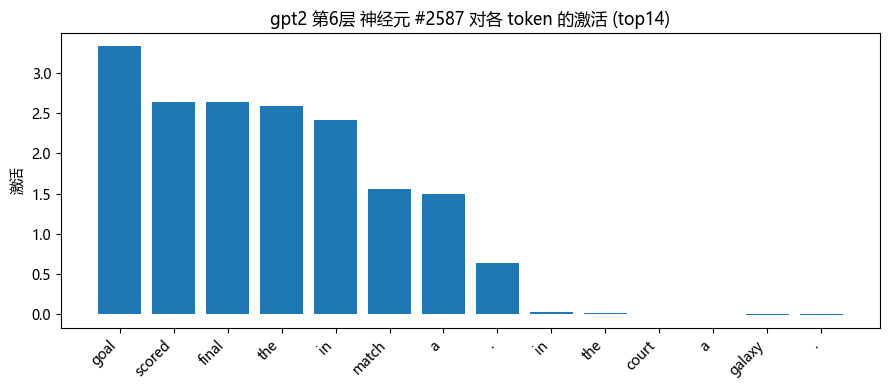

→ 这一个神经元对一堆不相关 token 都激活 → 它不是"一个概念一个神经元"。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
if neuron_acts:
    nid = int(cand[0])
    vals = acts[:, nid]
    order = np.argsort(-vals)[:14]
    fig, ax = plt.subplots(figsize=(9,4))
    ax.bar(range(len(order)), vals[order], color='C0')
    ax.set_xticks(range(len(order))); ax.set_xticklabels([toks[i] for i in order], rotation=45, ha='right')
    ax.set_title(f'gpt2 第{LAYER}层 神经元 #{nid} 对各 token 的激活 (top14)'); ax.set_ylabel('激活')
    plt.tight_layout(); plt.show()
    print('→ 这一个神经元对一堆不相关 token 都激活 → 它不是"一个概念一个神经元"。')

## 4. 反思
你在**真实 gpt2** 上看到了多义神经元 (superposition 的现象)。带走:
- **superposition**: 网络把多于神经元数的 feature 叠加压缩 → 单个神经元**多义** (对多个不相关概念激活)。
- 后果: **不能一个神经元一个神经元地读** —— 这是 mech interp 的头号难题。
- 解法方向: 读「方向」而非神经元 (线性探针 M12.2)、解叠加 (SAE M12.4)。
下一步 N2: 在受控玩具 transformer 上看激活如何编码概念 (为 probing 准备)。